# 复现 TLM 论文梯度内积实验

**论文**: Test-Time Learning for Large Language Models (arXiv: 2505.20633)

**核心假设** (Eq. 4):
$$\langle \nabla_x, \nabla_y \rangle = [\nabla_\Theta \log P(x;\theta)]^\top \nabla_\Theta \log P_\Theta(y|x) \geq 0$$

对于语义对齐的 QA 对，输入和输出的对数概率梯度内积应为非负。

**论文结果**: 400 batches × batch_size=50 = 20000 QA pairs on LLaMA3.1-8B, 98.75% 满足 ≥ 0, 平均值 +5.60

**本实验**: 使用 Qwen2.5-0.5B-Instruct (float16) 在 DomainBench (Geography, Agriculture, Medicine, Finance) 上复现

In [9]:
# Cell 1: 加载 DomainBench 数据集
# 数据来源: TLM 论文 GitHub repo (data/AdaptEval/)
# 四个领域文件，字段格式不完全一致：
#   - geosignal_random_5k.json: instruction, input, output, type, category
#   - agriculture-qa_random_5k.json: question, answers
#   - GenMedGPT_random_5k.json: instruction, input, output
#   - wealth-alpaca_lora_random_5k.json: instruction, input, output

import requests, json, random
from collections import Counter

random.seed(42)
BASE = "https://raw.githubusercontent.com/Fhujinwu/TLM/main/data/AdaptEval"

domain_files = {
    "Geography": "geosignal_random_5k.json",
    "Agriculture": "agriculture-qa_random_5k.json",
    "Medicine": "GenMedGPT_random_5k.json",
    "Finance": "wealth-alpaca_lora_random_5k.json",
}

samples = []
for domain, fname in domain_files.items():
    url = f"{BASE}/{fname}"
    print(f"下载 {domain}: {fname} ...", end=" ")
    data = requests.get(url).json()
    print(f"{len(data)} 条")
    
    for item in data:
        # 统一字段名
        if "question" in item:
            q = item["question"]
            a = item.get("answers", item.get("answer", ""))
        else:
            q = item.get("instruction", "")
            if item.get("input", "").strip():
                q = q + "\n" + item["input"]
            a = item.get("output", "")
        
        if len(q.strip()) > 10 and len(a.strip()) > 10:
            samples.append({"question": q.strip(), "answer": a.strip(), "domain": domain})

print(f"\n总共有效 QA 对: {len(samples)}")
domain_counts = Counter(s["domain"] for s in samples)
print(f"各领域分布: {dict(domain_counts)}")

# 每个领域采样 200 条，共 800 条
sampled = []
for domain in ["Geography", "Agriculture", "Medicine", "Finance"]:
    pool = [s for s in samples if s["domain"] == domain]
    n = min(200, len(pool))
    sampled.extend(random.sample(pool, n))
    print(f"  {domain}: 采样 {n} 条")

random.shuffle(sampled)
print(f"\n最终样本数: {len(sampled)}")
print(f"示例: Q={sampled[0]['question'][:100]}...")
print(f"      A={sampled[0]['answer'][:100]}...")

下载 Geography: geosignal_random_5k.json ... 5000 条
下载 Agriculture: agriculture-qa_random_5k.json ... 5000 条
下载 Medicine: GenMedGPT_random_5k.json ... 5000 条
下载 Finance: wealth-alpaca_lora_random_5k.json ... 5000 条

总共有效 QA 对: 19119
各领域分布: {'Geography': 4692, 'Agriculture': 4574, 'Medicine': 5000, 'Finance': 4853}
  Geography: 采样 200 条
  Agriculture: 采样 200 条
  Medicine: 采样 200 条
  Finance: 采样 200 条

最终样本数: 800
示例: Q=If you are a doctor, please answer the medical questions based on the patient's description.
Hi Doct...
      A=It sounds like you may have De Quervain disease. We can prescribe you some medications to help with ...


In [10]:
# Cell 2: 加载 Qwen2.5-0.5B-Instruct
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
model_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float32
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name, dtype=model_dtype, trust_remote_code=True
).cuda()
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"模型: {model_name}")
print(f"参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
print(f"设备: {next(model.parameters()).device}")
print(f"精度: {next(model.parameters()).dtype}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

模型: Qwen/Qwen2.5-0.5B-Instruct
参数量: 494.0M
设备: cuda:0
精度: torch.float16


In [11]:
# Cell 3: 核心计算函数 compute_grad_dot_logp
# 计算 ⟨∇θ log P(x;θ), ∇θ log P(y|x;θ)⟩
# 论文用的是 log P（对数概率），不是 loss
# log P(x) = Σ_t log P(x_t | x_{<t}) = -(N-1) * cross_entropy_loss
# （HuggingFace 内部 shift 后有 N-1 个预测位置）

import torch.nn.functional as F
from torch.nn.utils import parameters_to_vector

def compute_grad_dot_logp(model, tokenizer, question, answer, max_len=512):
    """计算一条 QA 对的梯度内积 ⟨∇θ log P(x), ∇θ log P(y|x)⟩"""
    device = next(model.parameters()).device
    named_params = [(name, p) for name, p in model.named_parameters() if p.requires_grad]
    params = [p for _, p in named_params]

    model.zero_grad(set_to_none=True)
    x_ids = tokenizer(question, return_tensors="pt", truncation=True, max_length=max_len).input_ids.to(device)
    n_x = x_ids.shape[1]
    n_x_loss = n_x - 1
    if n_x_loss <= 0:
        return float('nan'), float('nan'), float('nan')

    loss_x = model(input_ids=x_ids, labels=x_ids).loss
    log_p_x = -loss_x * n_x_loss
    grads_x = torch.autograd.grad(log_p_x, params, retain_graph=False, create_graph=False)
    log_p_x_val = log_p_x.item()

    bad_x = [name for (name, _), grad in zip(named_params, grads_x) if not torch.isfinite(grad).all()]
    if bad_x:
        print(f"⚠️ Non-finite grad in ∇log P(x); sample params: {bad_x[:3]}")
        model.zero_grad(set_to_none=True)
        return float('nan'), log_p_x_val, float('nan')

    y_ids = tokenizer(answer, return_tensors="pt", truncation=True, max_length=max_len, add_special_tokens=False).input_ids.to(device)
    xy_ids = torch.cat([x_ids, y_ids], dim=1)[:, :max_len]
    n_y = xy_ids.shape[1] - n_x
    if n_y <= 0:
        model.zero_grad(set_to_none=True)
        return float('nan'), log_p_x_val, float('nan')

    labels = xy_ids.clone()
    labels[:, :n_x] = -100

    loss_yx = model(input_ids=xy_ids, labels=labels).loss
    log_p_y_given_x = -loss_yx * n_y
    grads_y = torch.autograd.grad(log_p_y_given_x, params, retain_graph=False, create_graph=False)
    log_p_y_val = log_p_y_given_x.item()

    bad_y = [name for (name, _), grad in zip(named_params, grads_y) if not torch.isfinite(grad).all()]
    if bad_y:
        print(f"⚠️ Non-finite grad in ∇log P(y|x); skipped params: {bad_y[:3]}")
        model.zero_grad(set_to_none=True)
        return float('nan'), log_p_x_val, log_p_y_val

    gx = parameters_to_vector([grad.float() for grad in grads_x])
    gy = parameters_to_vector([grad.float() for grad in grads_y])
    dot_product = torch.dot(gx, gy).item()

    model.zero_grad(set_to_none=True)
    return dot_product, log_p_x_val, log_p_y_val

print("compute_grad_dot_logp 函数定义完成（autograd.grad + vector dot 版本）")

compute_grad_dot_logp 函数定义完成（已修复 fp16 溢出）


In [12]:
# Cell 4: Sanity Check（3 条样本）
import gc

print("=" * 60)
print("Sanity Check: 测试 3 条样本")
print("=" * 60)

for i in range(3):
    s = sampled[i]
    dot, lp_x, lp_y = compute_grad_dot_logp(model, tokenizer, s["question"], s["answer"])
    sign = "+" if dot >= 0 else "-"
    print(f"\n样本 {i} [{s['domain']}]:")
    print(f"  Q: {s['question'][:80]}...")
    print(f"  A: {s['answer'][:80]}...")
    print(f"  log P(x)   = {lp_x:.2f}")
    print(f"  log P(y|x) = {lp_y:.2f}")
    print(f"  内积 = {dot:.4f} [{sign}]")
    
    torch.cuda.empty_cache()
    gc.collect()

print("\nSanity check 完成!")

Sanity Check: 测试 3 条样本

样本 0 [Medicine]:
  Q: If you are a doctor, please answer the medical questions based on the patient's ...
  A: It sounds like you may have De Quervain disease. We can prescribe you some medic...
  log P(x)   = -87.34
  log P(y|x) = -218.30
  内积 = 3050071.7287 [+]

样本 1 [Geography]:
  Q: Would you mind telling me the subject of the Maps Database | Virtual Tianjin?...
  A: Not at all, the Maps Database | Virtual Tianjin's subject is Geological mapping....
  log P(x)   = -79.49
  log P(y|x) = -55.34
  内积 = 773803.2093 [+]

样本 2 [Finance]:
  Q: What happens when a non-U.S. citizen who's been making money from the U.S. moves...
  A: Its not for US citizens - its for US residents. If the US considers you as a tax...
  log P(x)   = -66.23
  log P(y|x) = -697.29
  内积 = -1419094.9964 [-]

Sanity check 完成!


In [13]:
# Cell 5: 主循环（全部样本）
from tqdm import tqdm
import math

results = []
n_errors = 0

print(f"开始计算 {len(sampled)} 条 QA 对的梯度内积...")
print(f"预计耗时较长，请耐心等待\n")

for i, s in enumerate(tqdm(sampled, desc="梯度内积计算")):
    try:
        dot, lp_x, lp_y = compute_grad_dot_logp(model, tokenizer, s["question"], s["answer"])
        
        # 检测点积爆炸
        if math.isnan(dot) or math.isinf(dot):
            print(f"⚠️ WARNING: sample {i} [{s['domain']}] dot={dot}, log_p_x={lp_x:.2f}, log_p_y={lp_y:.2f}")
            n_errors += 1
        else:
            results.append({
                "idx": i,
                "domain": s["domain"],
                "dot_product": dot,
                "log_p_x": lp_x,
                "log_p_y_given_x": lp_y,
                "question_preview": s["question"][:100],
                "answer_preview": s["answer"][:100],
            })
    except Exception as e:
        n_errors += 1
        if n_errors <= 3:
            print(f"  错误 [{i}]: {e}")
    
    # 每 20 条清理一次显存
    if (i + 1) % 20 == 0:
        torch.cuda.empty_cache()
        gc.collect()

print(f"\n计算完成! 成功: {len(results)}, 失败/爆炸: {n_errors}")
print(f"正内积比例: {sum(1 for r in results if r['dot_product'] >= 0) / len(results) * 100:.2f}%")

开始计算 800 条 QA 对的梯度内积...
预计耗时较长，请耐心等待



梯度内积计算:  22%|██▏       | 172/800 [09:22<58:29,  5.59s/it]  

⚠️ WARNING: sample 171 [Geography] dot=nan, log_p_x=0.00, log_p_y=0.00


梯度内积计算:  66%|██████▋   | 531/800 [17:57<02:31,  1.78it/s]  

⚠️ WARNING: sample 530 [Geography] dot=nan, log_p_x=0.00, log_p_y=0.00


梯度内积计算:  75%|███████▌  | 600/800 [18:38<02:02,  1.63it/s]

⚠️ WARNING: sample 599 [Geography] dot=nan, log_p_x=0.00, log_p_y=0.00


梯度内积计算: 100%|██████████| 800/800 [20:42<00:00,  1.55s/it]


计算完成! 成功: 797, 失败/爆炸: 3
正内积比例: 62.23%


In [14]:
# Cell 6: 统计分析
import pandas as pd
import numpy as np

df = pd.DataFrame(results)
dots = df["dot_product"].values

# 生成保存名（与 test.ipynb 一致的命名规范）
SAVE_NAME = f"results_reproduce_logp_{model_name.lower().replace('/', '_')}_{pd.Timestamp.now().strftime('%Y_%m_%d_%H%M')}"
print(f"SAVE_NAME: {SAVE_NAME}\n")

print("=" * 60)
print("整体统计")
print("=" * 60)
n_pos = (dots >= 0).sum()
n_total = len(dots)
pct_pos = n_pos / n_total * 100
print(f"总样本数:        {n_total}")
print(f"内积 ≥ 0:       {n_pos} ({pct_pos:.2f}%)")
print(f"内积 < 0:        {n_total - n_pos} ({100 - pct_pos:.2f}%)")
print(f"平均内积:        {dots.mean():.4f}")
print(f"中位数内积:      {np.median(dots):.4f}")
print(f"标准差:          {dots.std():.4f}")
print(f"最小值:          {dots.min():.4f}")
print(f"最大值:          {dots.max():.4f}")

print(f"\n--- 与 TLM 论文对比 ---")
print(f"TLM (LLaMA3.1-8B): 98.75% ≥ 0, 平均 +5.60")
print(f"本实验 ({model_name}): {pct_pos:.2f}% ≥ 0, 平均 {dots.mean():.4f}")

print(f"\n{'=' * 60}")
print("按领域分组统计")
print("=" * 60)
for domain in ["Geography", "Agriculture", "Medicine", "Finance"]:
    d = df[df["domain"] == domain]["dot_product"]
    if len(d) == 0:
        continue
    pos_pct = (d >= 0).sum() / len(d) * 100
    print(f"\n{domain} (n={len(d)}):")
    print(f"  ≥ 0 比例: {pos_pct:.2f}%")
    print(f"  均值: {d.mean():.4f}, 中位数: {d.median():.4f}")
    print(f"  范围: [{d.min():.4f}, {d.max():.4f}]")

SAVE_NAME: results_reproduce_logp_qwen_qwen2.5-0.5b-instruct_2026_03_21_2205

整体统计
总样本数:        797
内积 ≥ 0:       496 (62.23%)
内积 < 0:        301 (37.77%)
平均内积:        230766.9910
中位数内积:      173601.4093
标准差:          1183196.9570
最小值:          -4355194.8724
最大值:          8886713.6479

--- 与 TLM 论文对比 ---
TLM (LLaMA3.1-8B): 98.75% ≥ 0, 平均 +5.60
本实验 (Qwen/Qwen2.5-0.5B-Instruct): 62.23% ≥ 0, 平均 230766.9910

按领域分组统计

Geography (n=197):
  ≥ 0 比例: 72.59%
  均值: 482967.5366, 中位数: 331828.2387
  范围: [-3135963.4359, 8791782.1816]

Agriculture (n=200):
  ≥ 0 比例: 62.00%
  均值: 156013.2757, 中位数: 133479.0302
  范围: [-1850685.0165, 3242110.5782]

Medicine (n=200):
  ≥ 0 比例: 52.50%
  均值: 48160.8370, 中位数: 81687.0266
  范围: [-4355194.8724, 5599307.3743]

Finance (n=200):
  ≥ 0 比例: 62.00%
  均值: 239709.3230, 中位数: 95599.3105
  范围: [-3000646.0380, 8886713.6479]


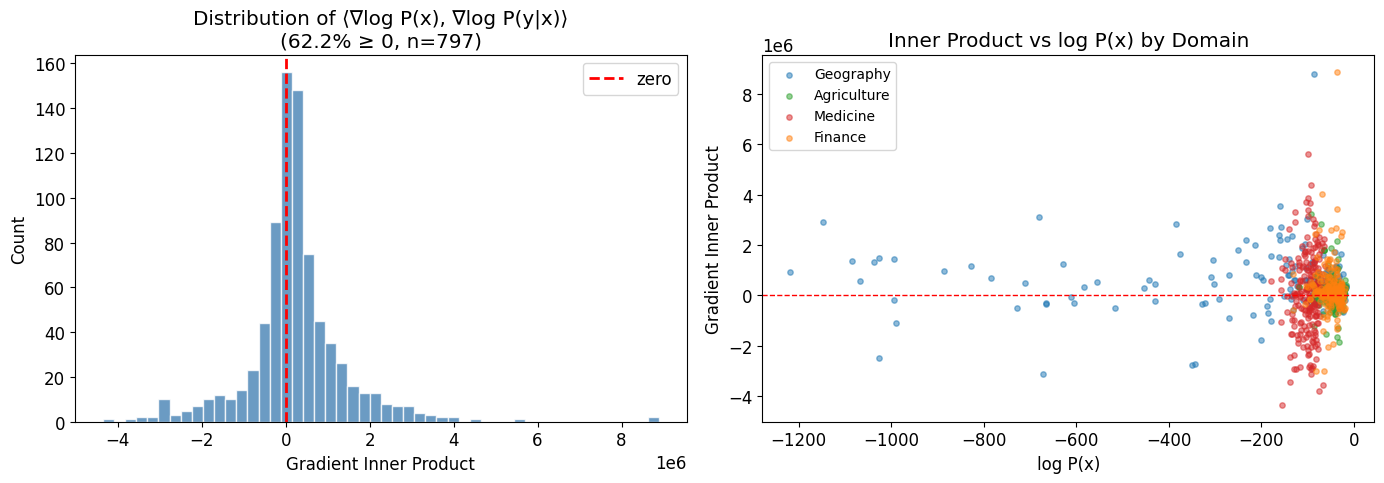

图片已保存: results_reproduce_logp_qwen_qwen2.5-0.5b-instruct_2026_03_21_2205_gradient_dot.png


In [15]:
# Cell 7: 可视化
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左图: 直方图 ---
ax = axes[0]
ax.hist(dots, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='zero')
ax.set_xlabel('Gradient Inner Product')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of ⟨∇log P(x), ∇log P(y|x)⟩\n'
             f'({pct_pos:.1f}% ≥ 0, n={n_total})')
ax.legend()

# --- 右图: 按领域的散点图 ---
ax = axes[1]
domain_colors = {"Geography": "tab:blue", "Agriculture": "tab:green", 
                 "Medicine": "tab:red", "Finance": "tab:orange"}
for domain, color in domain_colors.items():
    mask = df["domain"] == domain
    subset = df[mask]
    ax.scatter(subset["log_p_x"], subset["dot_product"], 
               c=color, alpha=0.5, s=15, label=domain)

ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('log P(x)')
ax.set_ylabel('Gradient Inner Product')
ax.set_title('Inner Product vs log P(x) by Domain')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"D:/llm-tta/{SAVE_NAME}_gradient_dot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"图片已保存: {SAVE_NAME}_gradient_dot.png")

In [16]:
# Cell 8: 保存结果
df.to_csv(f"D:/llm-tta/{SAVE_NAME}.csv", index=False, encoding="utf-8-sig")
print(f"结果已保存: {SAVE_NAME}.csv")
print(f"共 {len(df)} 条记录")
print(f"\n列名: {list(df.columns)}")
print(f"\n前 5 条:")
df.head()

结果已保存: results_reproduce_logp_qwen_qwen2.5-0.5b-instruct_2026_03_21_2205.csv
共 797 条记录

列名: ['idx', 'domain', 'dot_product', 'log_p_x', 'log_p_y_given_x', 'question_preview', 'answer_preview']

前 5 条:


,idx,domain,dot_product,log_p_x,log_p_y_given_x,question_preview,answer_preview
0,0,Medicine,3.050072e+06,-87.337646,-218.297745,"If you are a doctor, please answer the medical...",It sounds like you may have De Quervain diseas...
1,1,Geography,7.738032e+05,-79.493835,-55.341183,Would you mind telling me the subject of the M...,"Not at all, the Maps Database | Virtual Tianji..."
2,2,Finance,-1.419095e+06,-66.231674,-697.292236,What happens when a non-U.S. citizen who's bee...,Its not for US citizens - its for US residents...
3,3,Geography,-7.943927e+05,-217.408951,-235.617432,"Anyone here working on neogene ""chaetetid"" spo...","Dear Enrique,\nYou may also think of contactin..."
4,4,Finance,9.919606e+05,-51.380325,-417.102417,Foolish to place orders before the market opens?,"Depending on your strategy, it could be though..."
